<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/Survival-function-analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Load dataset

In [9]:
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)
data.rename(columns={"0_na, 1_mi": "severity", "0_no, 1_ther, 2_card": "doctor"}, inplace=True);
data.drop(columns=["card"], inplace=True)
data.drop(columns=["na"], inplace=True)
data.drop(columns=["dmonit"], inplace=True)
data["target"] = data["result_cvd"]
data.drop(columns=["result", "result_cvd"], inplace=True)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = data.copy()

# Separate majority and minority classes
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x788e061e4860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error



Class 0 samples: 1354
Class 1 samples: 152


## Method 1: Downsample majority class to match minority class

In [10]:

# Method 1: Downsample majority class to match minority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,  # sample without replacement
                                   n_samples=len(df_minority),  # match minority class size
                                   random_state=37)  # reproducible results

# Combine downsampled majority with minority
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

print(f"\nAfter downsampling - balanced dataset:")
print(df_downsampled['target'].value_counts())
print(f"Total samples after downsampling: {len(df_downsampled)}")


After downsampling - balanced dataset:
target
0    152
1    152
Name: count, dtype: int64
Total samples after downsampling: 304


## Method 2: Upsample minority class using SMOTE to match majority class

In [11]:
# Method 2: Upsample minority class using SMOTE to match majority class
# Prepare data for SMOTE: features and target
X_smote = df.drop('target', axis=1)
y_smote = df['target']

smote = SMOTE(random_state=37)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# Combine resampled features and target into a new DataFrame
df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)

print(f"\nAfter upsampling with SMOTE - balanced dataset:")
print(df_upsampled['target'].value_counts())
print(f"Total samples after upsampling: {len(df_upsampled)}")


After upsampling with SMOTE - balanced dataset:
target
0    1354
1    1354
Name: count, dtype: int64
Total samples after upsampling: 2708


In [12]:
y = df_upsampled['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df_upsampled.drop(columns=columns_to_drop_for_regressor)

In [13]:
# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2166, 30)  |  Test: (542, 30)


# 0. Решаем задачу регрессии для time

In [14]:
# линейная регрессия
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"  R²   = {lr_r2:.4f}")
print(f"  RMSE = {lr_rmse:.4f}")
print(f"  MAE  = {lr_mae:.4f}")
print(f"\nКоэффициенты модели:")
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_}).sort_values('coef')
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.4826
  RMSE = 389.9284
  MAE  = 316.6099

Коэффициенты модели:
     feature       coef
    severity -82.192957
         glu -72.457361
        crea -61.649805
         bpm -52.362951
         ldl -46.822007
         age -46.059769
   pulm_cong -28.570592
         llo  -8.439040
     sum_cad  -0.346749
          hb   0.441079
      leukoc   0.529431
        onco   4.139093
        copd   7.756621
     tromboc   9.780790
      insult  12.959180
     ef_hosp  14.731043
          af  24.064542
      gender  34.445668
       sysAP  34.698107
    stenting  37.332949
    ca_delay  37.888564
         bmi  43.260171
         ckd  43.435428
      nstemi  44.681167
     smoking  45.822414
          dm  66.647591
total_revasc  82.414948
       stemi  82.612745
      t_chol 111.145819
      doctor 198.720653


In [15]:
# деревья решений
dt_reg = DecisionTreeRegressor(random_state=37, max_depth=10)
dt_reg.fit(X_train_sc, y_train)

y_pred_dt = dt_reg.predict(X_test_sc)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

# Train vs Test — проверяем переобучение
dt_r2_train = r2_score(y_train, dt_reg.predict(X_train_sc))

print("Decision Tree (max_depth=10)")
print(f"  Train R² = {dt_r2_train:.4f}")
print(f"  Test  R² = {dt_r2:.4f}")
print(f"  RMSE     = {dt_rmse:.4f}")
print(f"  MAE      = {dt_mae:.4f}")
if dt_r2_train - dt_r2 > 0.1:
    print("Внимание: разрыв Train/Test > 0.1 — возможно переобучение!")

Decision Tree (max_depth=10)
  Train R² = 0.8636
  Test  R² = 0.3424
  RMSE     = 439.6162
  MAE      = 293.4823
Внимание: разрыв Train/Test > 0.1 — возможно переобучение!


Random Forest (100 деревьев, max_depth=10)
  R²   = 0.6561
  RMSE = 317.9243
  MAE  = 242.7310


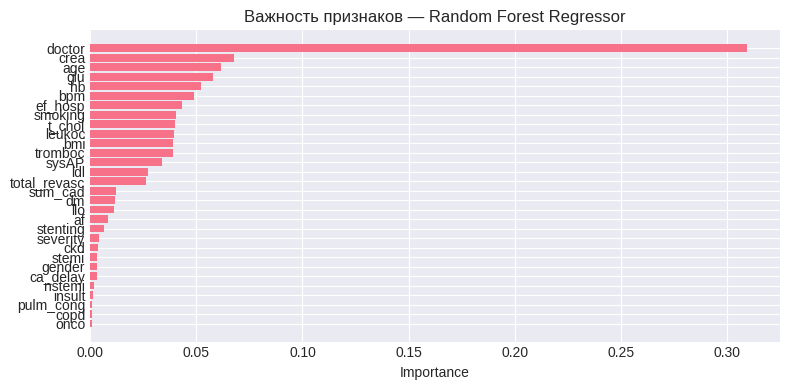

In [16]:
# случайный лес
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train_sc, y_train)

y_pred_rf = rf_reg.predict(X_test_sc)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:.4f}")
print(f"  MAE  = {rf_mae:.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Важность признаков — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Gradient Boosting (100 деревьев, max_depth=5)
  R²   = 0.6086
  RMSE = 339.1516
  MAE  = 268.6412


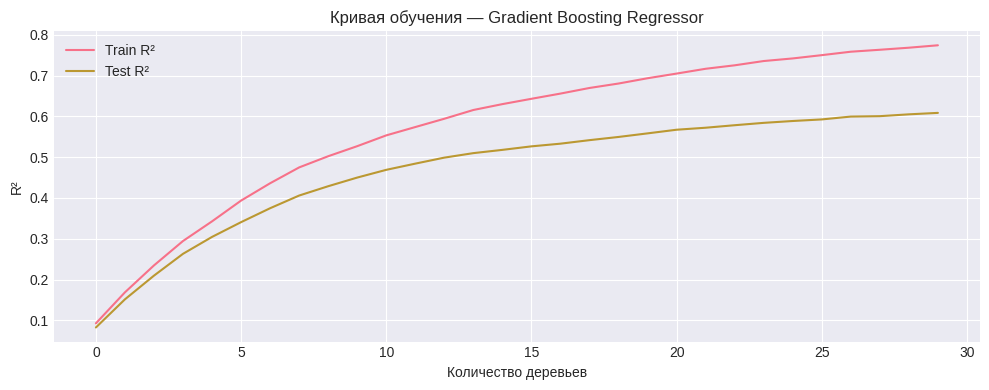

In [17]:
# градиентный бустинг
gb_reg = GradientBoostingRegressor(n_estimators=30, random_state=42, max_depth=5)
gb_reg.fit(X_train_sc, y_train)

y_pred_gb = gb_reg.predict(X_test_sc)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  R²   = {gb_r2:.4f}")
print(f"  RMSE = {gb_rmse:.4f}")
print(f"  MAE  = {gb_mae:.4f}")

# Кривая обучения (staged_predict)
train_scores = [r2_score(y_train, y_pred) for y_pred in gb_reg.staged_predict(X_train_sc)]
test_scores  = [r2_score(y_test,  y_pred) for y_pred in gb_reg.staged_predict(X_test_sc)]

plt.figure(figsize=(10, 4))
plt.plot(train_scores, label='Train R²', linewidth=1.5)
plt.plot(test_scores,  label='Test R²',  linewidth=1.5)
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Кривая обучения — Gradient Boosting Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Сводная таблица — Регрессия:
                       R²      RMSE       MAE
Model                                        
Linear Regression  0.4826  389.9284  316.6099
Decision Tree      0.3424  439.6162  293.4823
Random Forest      0.6561  317.9243  242.7310
Gradient Boosting  0.6086  339.1516  268.6412

Лучшая модель по R²: Random Forest (0.6561)


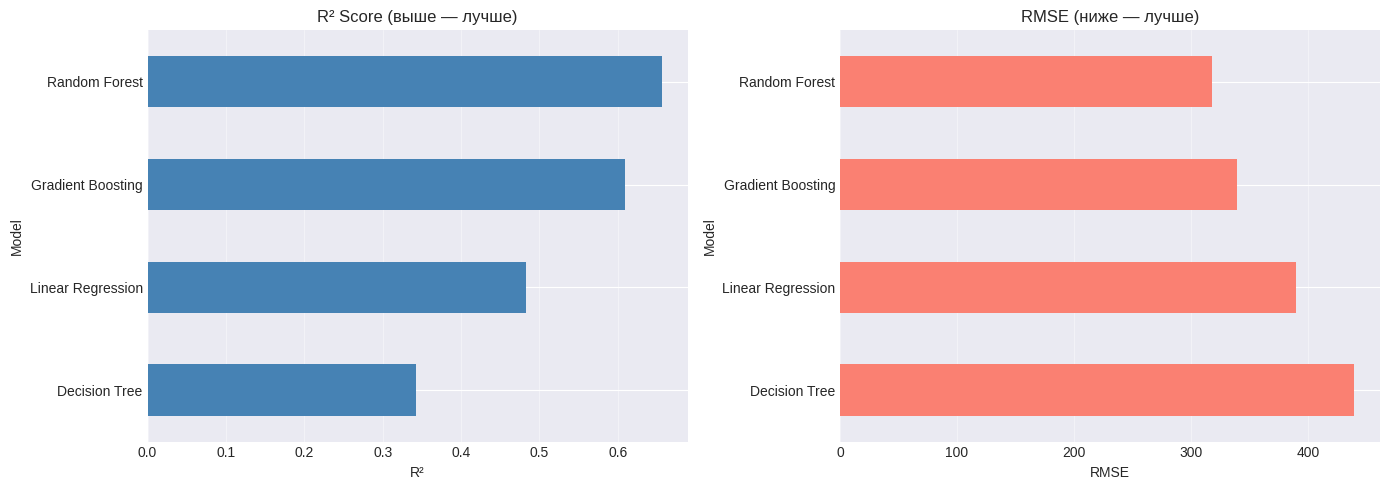

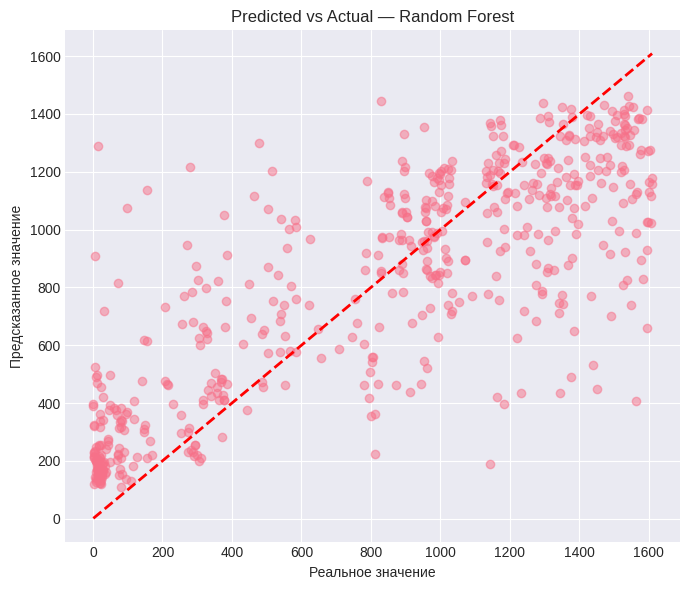

In [18]:
# сравниваем методы
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R²':   [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae]
}).set_index('Model').round(4)

print("Сводная таблица — Регрессия:")
print(reg_summary.to_string())

best_reg = reg_summary['R²'].idxmax()
print(f"\nЛучшая модель по R²: {best_reg} ({reg_summary.loc[best_reg, 'R²']:.4f})")

# График сравнения R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_summary['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (выше — лучше)')
axes[0].set_xlabel('R²')
axes[0].grid(axis='x', alpha=0.4)

reg_summary['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('RMSE (ниже — лучше)')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

#для лучшей модели
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}
y_best = best_pred_map[best_reg]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title(f'Predicted vs Actual — {best_reg}')
plt.tight_layout()
plt.show()

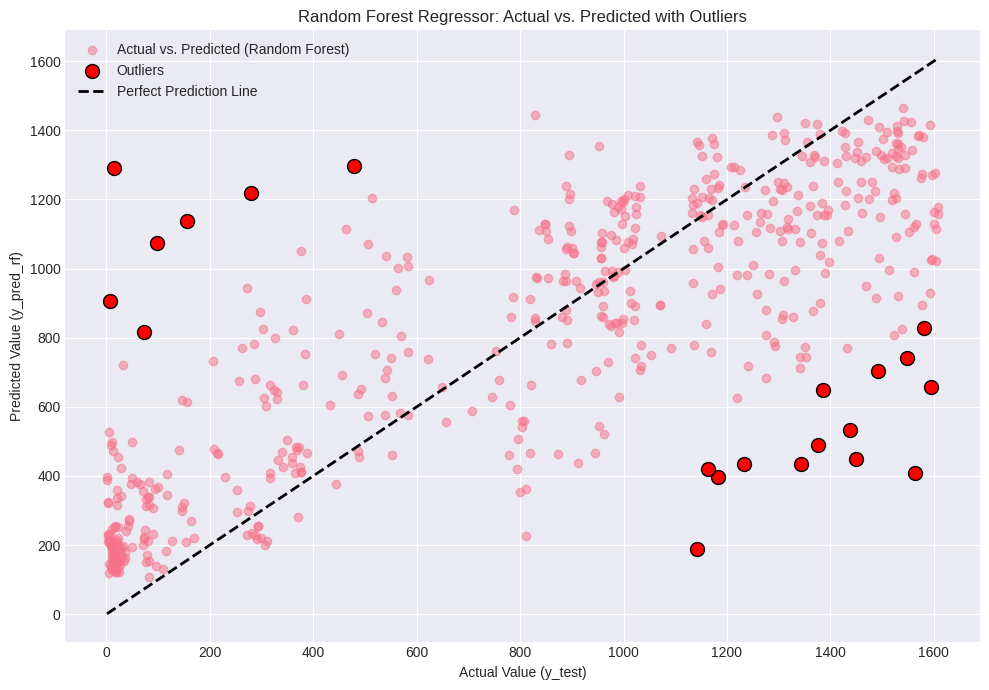


Number of outlier predictions: 21
Lower bound for residual outliers: -715.36
Upper bound for residual outliers: 726.45

--- Outlier Samples (Actual vs. Predicted) ---
      Actual    Predicted     Residual
329     1492   702.534481   789.465519
520     1563   407.574880  1155.425120
1387       7   907.407204  -900.407204
1519     156  1137.445064  -981.445064
2553    1385   648.918173   736.081827
954     1344   435.888420   908.111580
347     1594   658.130194   935.869806
494     1450   448.494231  1001.505769
479     1377   489.071289   887.928711
1970    1143   188.655524   954.344476
67      1549   739.908014   809.091986
2275    1233   434.019234   798.980766
513       72   816.757179  -744.757179
1638    1183   396.393575   786.606425
826     1438   533.116741   904.883259
2178    1163   420.871006   742.128994
1061     478  1298.156292  -820.156292
320       98  1074.947143  -976.947143
1461     279  1217.974639  -938.974639
21        14  1289.868443 -1275.868443
1029    1582 

In [19]:
# Calculate residuals (errors)
residuals = y_test - y_pred_rf

# Calculate IQR for residuals
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

# Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Actual vs. Predicted (Random Forest)')
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Lower bound for residual outliers: {lower_bound_res:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})
print(outlier_df.to_string())

--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---


,Actual,Predicted,Residual
1008,567,581.332389,-14.332389
1789,486,471.640103,14.359897
2648,989,989.260014,-0.260014
1460,1164,1155.414094,8.585906
1262,860,781.473058,78.526942


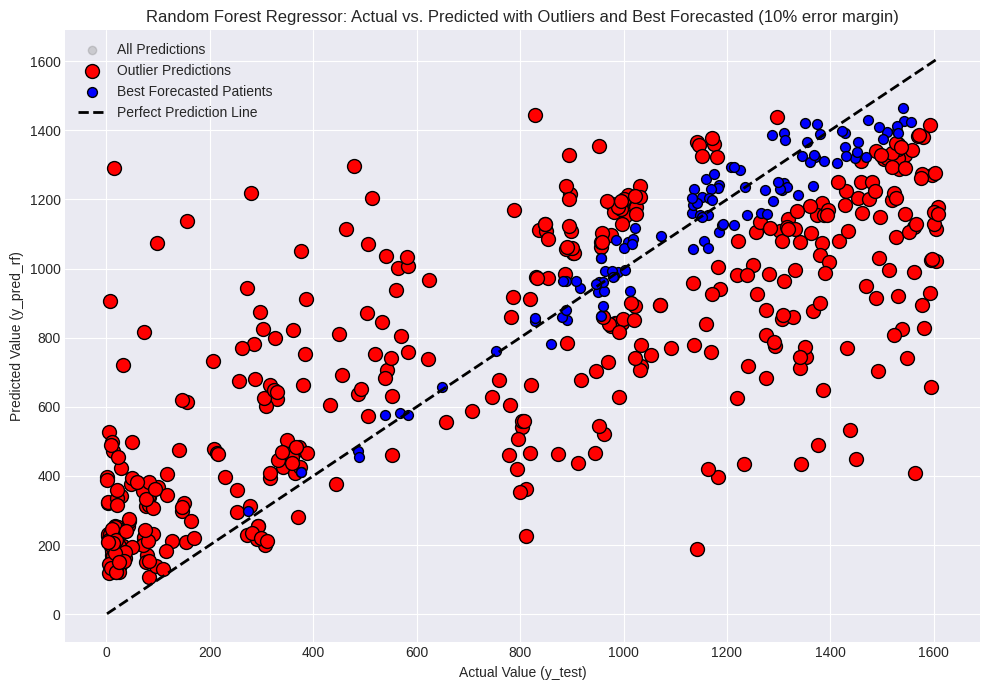


Number of outlier predictions: 429
Number of best forecasted patients: 113
Error margin for acceptable residuals: +/- 10% of actual value

--- Outlier Samples (Actual vs. Predicted) ---

--- Real Outlier Samples ---
     Actual    Predicted     Residual
0    1527.0  1325.138136   201.861864
1     464.0  1114.623766  -650.623766
2    1384.0  1074.189998   309.810002
3     376.0  1049.743573  -673.743573
4    1460.0  1249.177065   210.822935
5    1022.0   892.057446   129.942554
6     759.0   677.660589    81.339411
7     504.0   870.437312  -366.437312
8       3.0   320.753614  -317.753614
9    1033.0   779.908490   253.091510
10    745.0   629.315219   115.684781
11    828.0  1444.359861  -616.359861
12     76.0   313.477337  -237.477337
13   1545.0  1327.221461   217.778539
14   1530.0  1360.687857   169.312143
15    303.0   826.424524  -523.424524
16    812.0   224.705061   587.294939
17   1174.0  1360.856562  -186.856562
18   1580.0  1381.500371   198.499629
19   1025.0  1177.02898

In [20]:
residuals = y_test - y_pred_rf

# Define 'best forecasted patients' based on a 10% error margin
# A prediction is 'best' if its absolute error is within 10% of the actual value.
error_margin = 0.10 # 10%

# Calculate lower and upper bounds for predictions to be considered 'best'
# Predicted value should be between (Actual * (1 - error_margin)) and (Actual * (1 + error_margin))
# This implies: Actual - (Actual * error_margin) <= Predicted <= Actual + (Actual * error_margin)
# Rearranging: -(Actual * error_margin) <= Predicted - Actual <= (Actual * error_margin)
# Or: -abs(Actual * error_margin) <= Residual <= abs(Actual * error_margin)

# For each actual value in y_test, define its acceptable residual range
acceptable_residual_lower_bound = -np.abs(y_test * error_margin)
acceptable_residual_upper_bound = np.abs(y_test * error_margin)

# Identify 'best forecasted patients' based on the new error margin
best_forecasted_mask = (residuals >= acceptable_residual_lower_bound) & (residuals <= acceptable_residual_upper_bound)

# Identify 'outlier predictions' as those NOT in the best forecasted group
outlier_mask = ~best_forecasted_mask

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

best_forecasted_y_test = y_test[best_forecasted_mask]
best_forecasted_y_pred_rf = y_pred_rf[best_forecasted_mask]

# Create DataFrame for best forecasted patients
best_forecasted_df = pd.DataFrame({
    'Actual': best_forecasted_y_test,
    'Predicted': best_forecasted_y_pred_rf,
    'Residual': residuals[best_forecasted_mask]
})

print("--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---")
display(best_forecasted_df.head())

# Plotting actual vs. predicted values with outliers and best forecasted patients highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='All Predictions', color='gray') # All points in gray
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outlier Predictions', edgecolors='black')
plt.scatter(best_forecasted_y_test, best_forecasted_y_pred_rf, color='blue', s=50, label='Best Forecasted Patients', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers and Best Forecasted (10% error margin)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Number of best forecasted patients: {len(best_forecasted_y_test)}")
print(f"Error margin for acceptable residuals: +/- {error_margin*100:.0f}% of actual value")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})

# Determine the threshold for original samples based on the length of the original `data` DataFrame
original_data_length = len(data)

# Create lists to store real and SMOTE-generated outlier samples
real_outliers = []
smote_outliers = []

for original_upsampled_index, row in outlier_df.iterrows():
    if original_upsampled_index < original_data_length:
        # This index corresponds to an original sample
        real_outliers.append(row.to_dict())
    else:
        # This index corresponds to a SMOTE-generated sample
        smote_outliers.append(row.to_dict())

print("\n--- Real Outlier Samples ---")
if real_outliers:
    print(pd.DataFrame(real_outliers).to_string())
else:
    print("No real outlier samples found.")

print("\n--- SMOTE-Generated Outlier Samples ---")
if smote_outliers:
    print(pd.DataFrame(smote_outliers).to_string())
else:
    print("No SMOTE-generated outlier samples found.")

In [21]:
real_outliers_df = pd.DataFrame(real_outliers)
real_outlier_indices = real_outliers_df.index

print("Real Outlier Samples from the original `data` DataFrame:")
display(data.loc[real_outlier_indices])

Real Outlier Samples from the original `data` DataFrame:


,doctor,time,age,af,dm,ckd,copd,insult,onco,severity,...,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea,target
0,1,1152,79.0,0,1,0,0,0,0,0,...,30.7,0,84.0,7.1,213.0,2.2,1.06,8.7,117.0,0
1,1,949,61.0,1,1,0,0,0,1,1,...,34.0,0,166.0,9.4,225.0,5.8,3.61,4.4,94.0,0
2,1,1135,49.0,0,0,0,0,0,0,1,...,23.0,1,150.0,10.5,208.0,7.4,5.09,3.9,74.0,0
3,2,1524,59.0,0,0,0,0,0,0,1,...,26.5,1,142.0,5.1,58.0,5.3,3.30,4.2,86.0,0
4,2,1396,55.0,0,0,0,0,0,0,1,...,29.0,1,151.0,7.7,305.0,7.3,5.07,4.3,96.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2,1549,68.0,0,1,0,0,0,0,1,...,45.0,0,128.0,8.0,276.0,7.5,5.42,8.5,83.0,0
215,2,1282,61.0,0,0,0,0,0,0,1,...,34.5,1,144.0,16.5,301.0,6.9,4.60,6.7,76.0,0
216,2,1019,67.0,0,0,0,0,0,1,1,...,29.0,0,109.0,11.6,221.0,5.3,3.24,6.1,43.0,0
217,2,1159,73.0,0,0,0,0,0,0,1,...,29.0,1,134.0,9.4,176.0,4.6,2.90,4.5,68.0,0


In [29]:
import shap
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)

# Усреднённое влияние llo на вероятность result=1
llo_idx = list(X_test.columns).index('llo')
print(f"Mean SHAP for llo: {shap_values[:, llo_idx].mean():.4f}")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

ImportError: Numba needs NumPy 2.0 or less. Got NumPy 2.5.

# Оценка функции выживаемости

 ## 1. Cox Proportional Hazards

 Code implements a Cox Proportional Hazards (CoxPH) model, which is the most common semi-parametric model for survival analysis.

In [30]:
!pip install lifelines -q

In [31]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

# Reconstruct the training data for CoxPHFitter using scaled features
# X_train_sc is a numpy array, convert it to DataFrame
X_train_sc_df = pd.DataFrame(X_train_sc, columns=original_gb_reg_features, index=X_train.index)

# Add 'time' (duration) and 'target' (event) from df_upsampled using the correct indices
cph_data_train_scaled = X_train_sc_df.copy()
cph_data_train_scaled['time'] = y_train # y_train already has correct indices and duration values
cph_data_train_scaled['target'] = df_upsampled.loc[X_train.index, 'target'] # Get target for training indices

# Drop any NaN values that might have been introduced if indices mismatch
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Learning model
cph = CoxPHFitter()
cph.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
cph.print_summary()

# Evaluate survival function (Concordance Index) using X_test_sc
# First, prepare the test data similarly
X_test_sc_df = pd.DataFrame(X_test_sc, columns=original_gb_reg_features, index=X_test.index)
cph_data_test_scaled = X_test_sc_df.copy()
cph_data_test_scaled['time'] = y_test # y_test has correct indices and duration values
cph_data_test_scaled['target'] = df_upsampled.loc[X_test.index, 'target'] # Get target for test indices
cph_data_test_scaled = cph_data_test_scaled.dropna()

# Calculate concordance index
concordance_index = cph.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nConcordance Index on test set: {concordance_index:.4f}")

<lifelines.CoxPHFitter: fitted with 2166 total observations, 1088 right-censored observations>
             duration col = 'time'
                event col = 'target'
      baseline estimation = breslow
   number of observations = 2166
number of events observed = 1078
   partial log-likelihood = -7033.58
         time fit was run = 2026-07-07 08:45:41 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
doctor       -0.55      0.58      0.04           -0.63           -0.47                0.53                0.62
age           0.17      1.19      0.04            0.09            0.26                1.09                1.30
af           -0.10      0.90      0.03           -0.17           -0.04                0.84                0.96
dm           -0.45      0.64      0.05           -0.54           -0.35                0.58                0.70
ckd          -0.10      0.91      0.03           -0.16           -0.03                0.85                0.97
copd         -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
insult       -0.17      0.84      0.05           -0.26           -0.08                0.77                0.92
onco         -0.10      0.91      0.07           -0.24            0.04                0.79                1.04
severity      0.15      1.17      0.05            0.06            0.25                1.06                1.28
nstemi       -0.26      0.77      0.05           -0.36           -0.16                0.70                0.85
stemi        -0.24      0.79      0.05           -0.34           -0.14                0.71                0.87
llo          -0.44      0.64      0.08           -0.60           -0.29                0.55                0.75
gender       -0.15      0.86      0.04           -0.24           -0.07                0.79                0.93
ca_delay     -0.30      0.74      0.06           -0.41           -0.19                0.66                0.83
sum_cad      -0.03      0.97      0.04           -0.10            0.05                0.90                1.05
stenting     -0.16      0.85      0.03           -0.23           -0.10                0.80                0.91
total_revasc -0.36      0.69      0.04           -0.44           -0.29                0.64                0.75
ef_hosp      -0.08      0.93      0.04           -0.15           -0.00                0.86                1.00
bpm           0.16      1.18      0.03            0.10            0.23                1.10                1.26
sysAP        -0.14      0.87      0.03           -0.21           -0.08                0.81                0.93
pulm_cong     0.03      1.03      0.03           -0.04            0.10                0.96                1.10
bmi          -0.24      0.79      0.04           -0.32           -0.16                0.73                0.85
smoking      -0.21      0.81      0.05           -0.30           -0.12                0.74                0.89
hb            0.06      1.06      0.04           -0.02            0.13                0.98                1.14
leukoc        0.04      1.04      0.04           -0.04            0.11                0.96                1.11
tromboc      -0.07      0.94      0.03           -0.13           -0.00                0.88                1.00
t_chol       -0.51      0.60      0.11           -0.71           -0.30                0.49                0.74
ldl           0.34      1.41      0.10            0.14            0.54                1.15                1.72
glu           0.28      1.32      0.03            0.21            0.34                1.23                1.41
crea          0.08      1.08      0.03            0.02            0.13                1.02                1.14

              cmp to      z      p  -log2(p)
covariate                              


Concordance Index on test set: 0.8374


The C-index ranges from 0.5 to 1.0:0.5: Indicates a completely random prediction, meaning the model has no predictive discrimination power.1.0: Indicates perfect concordance (the model flawlessly ranks all subjects based on their actual time-to-event).Example: A C-index of 0.78 means that for any two randomly selected subjects, the model will correctly identify which subject will experience the event earlier 78% of the time.

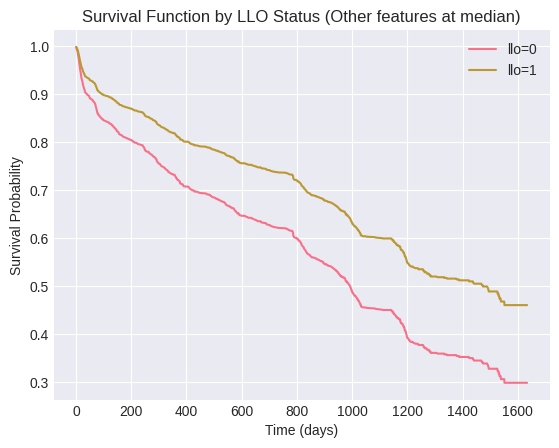

In [32]:
from lifelines import CoxPHFitter

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting the CPH model.
# Drop 'time' and 'target' as they are not features for prediction.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T


# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function
cph.predict_survival_function(plot_data).plot()
plt.title('Survival Function by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

**Интерпретация графика функции выживаемости по статусу LLO:**

Survival function говорит о «накопленном успехе» (кто остался). Этот график функции выживаемости демонстрирует прогнозируемую вероятность выживания с течением времени для двух групп пациентов, различающихся только по статусу `llo` (факт получения лекарственного обеспечения):

*   **Красная линия (llo=0):** Представляет пациентов, которые **не** получают бесплатное лекарственное обеспечение. Кривая начинается со 100% выживаемости и постепенно снижается, показывая, как вероятность выживания уменьшается со временем.

*   **Желтая линия (llo=1):** Представляет пациентов, которые **получают** бесплатное лекарственное обеспечение.

**Вывод:** Визуально видно, что группа пациентов с `llo=1` (получающая льготное лекарственное обеспечение) имеет **более высокую вероятность выживания** по сравнению с группой `llo=0` (не получающей такое обеспечение). Это означает, что получение бесплатного лекарственного обеспечения после выписки ассоциируется с увеличением времени до наступления события (например, смерти) и, следовательно, с улучшением прогноза выживаемости, при условии, что другие факторы остаются на среднем уровне.

### feature importance

In [19]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define a prediction wrapper function for the CoxPHFitter model.
# SHAP's KernelExplainer expects a function that takes a 2D numpy array
# and returns a 1D numpy array of predictions (e.g., expected survival time).
# The cph.predict_expectation method expects a DataFrame with named columns.
def cph_predict_expectation_wrapper(X_scaled_array):
    # Ensure the input array has the correct feature names and is a DataFrame
    # original_gb_reg_features should contain the names of all features in X_test_sc/X_train_sc
    X_df = pd.DataFrame(X_scaled_array, columns=original_gb_reg_features)
    # Predict expected lifetime
    return cph.predict_expectation(X_df).values

# For KernelExplainer, it's good practice to use a background dataset (e.g., a sample of X_train_sc).
# A smaller background dataset will run faster but might be less accurate.
# Let's use a sample of 100 observations from X_train_sc.
explainer_background = shap.sample(X_train_sc, 3)

# Initialize SHAP KernelExplainer with the wrapper function and background data
explainer = shap.KernelExplainer(cph_predict_expectation_wrapper, explainer_background)


In [20]:

# Calculate SHAP values for the test set. This can be computationally intensive.
# For demonstration, we might sample X_test_sc if it's very large.
# Using the full X_test_sc here as it's not excessively large (542 samples).
print("Calculating SHAP values for the CoxPH model's expected survival... This may take a while.")
shap_values_cph = explainer.shap_values(X_test_sc)

Calculating SHAP values for the CoxPH model's expected survival... This may take a while.


  0%|          | 0/542 [00:00<?, ?it/s]

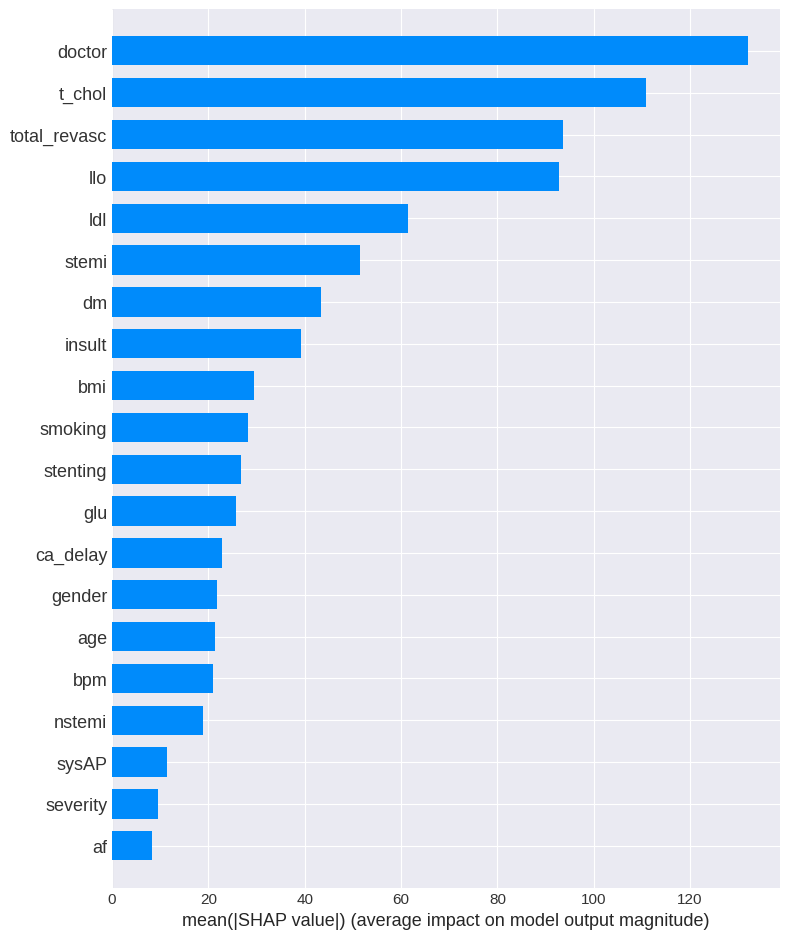

In [21]:

# Create a SHAP summary plot (bar) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features, plot_type="bar")
#plt.title('Feature Importance (SHAP values) for CPH Expected Survival')
plt.show()

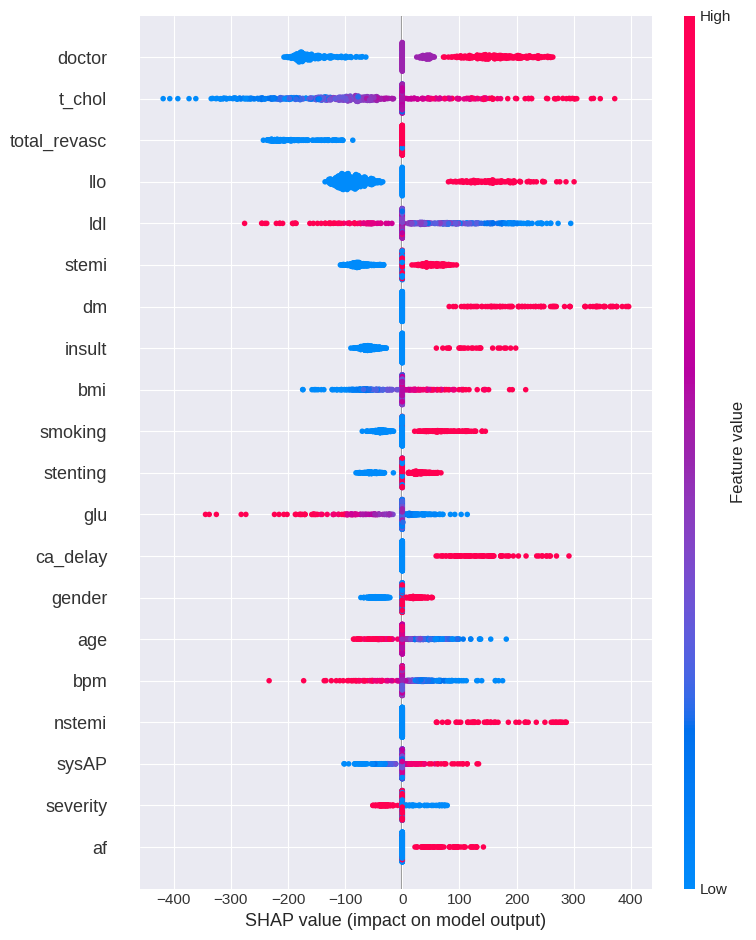

Interpretation of the SHAP summary plots for CoxPH Expected Survival:
- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.
- The dot plot provides more detail: 
  - Each dot represents a data point from the test set.
  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.
  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.
  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.


In [22]:
# Create a SHAP summary plot (dots) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features)
#plt.title('Feature Impact (SHAP values) for CPH Expected Survival')
plt.show()

print("Interpretation of the SHAP summary plots for CoxPH Expected Survival:")
print("- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.")
print("- The dot plot provides more detail: ")
print("  - Each dot represents a data point from the test set.")
print("  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.")
print("  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.")
print("  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.")

## 2. Weibull

<lifelines.WeibullAFTFitter: fitted with 2166 total observations, 1088 right-censored observations>
             duration col = 'time'
                event col = 'target'
   number of observations = 2166
number of events observed = 1078
           log-likelihood = -7921.09
         time fit was run = 2026-07-07 09:10:23 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ af            0.15      1.16      0.05            0.05            0.24                1.05                1.27
        age          -0.25      0.78      0.06           -0.37           -0.13                0.69                0.88
        bmi           0.33      1.39      0.05            0.22            0.44                1.25                1.55
        bpm          -0.25      0.78      0.05           -0.35           -0.16                0.71                0.85
        ca_delay      0.39      1.48      0.08            0.24            0.55                1.27                1.73
        ckd           0.15      1.16      0.04            0.06            0.23                1.06                1.26
        copd          0.06      1.06      0.06           -0.06            0.17                0.95                1.19
        crea         -0.09      0.91      0.04           -0.17           -0.01                0.84                0.99
        dm            0.64      1.90      0.07            0.51            0.78                1.66                2.18
        doctor        0.80      2.23      0.06            0.69            0.91                1.98                2.50
        ef_hosp       0.10      1.11      0.05           -0.00            0.21                1.00                1.23
        gender        0.22      1.24      0.06            0.10            0.33                1.11                1.40
        glu          -0.39      0.67      0.05           -0.49           -0.30                0.61                0.74
        hb           -0.12      0.88      0.05           -0.22           -0.02                0.80                0.98
        insult        0.23      1.26      0.06            0.11            0.36                1.11                1.43
        ldl          -0.47      0.63      0.14           -0.75           -0.19                0.47                0.83
        leukoc       -0.02      0.98      0.05           -0.12            0.08                0.89                1.08
        llo           0.63      1.88      0.11            0.42            0.85                1.52                2.33
        nstemi        0.32      1.38      0.07            0.18            0.46                1.20                1.59
        onco          0.13      1.14      0.10           -0.06            0.32                0.94                1.38
        pulm_cong    -0.04      0.96      0.05           -0.14            0.05                0.87                1.05
        severity     -0.18      0.84      0.07           -0.31           -0.04                0.74                0.96
        smoking       0.29      1.34      0.07            0.16            0.42                1.17                1.53
        stemi         0.27      1.31      0.07            0.13            0.41                1.14                1.51
        stenting      0.23      1.26      0.05            0.14            0.32                1.15                1.38
        sum_cad       0.05      1.05      0.05           -0.05            0.15                0.95                1.17
        sysAP         0.21      1.24      0.05            0.12            0.30                1.13                1.36
        t_chol        0.70      2.02      0.15            0.42            0.99                1.52                2.70
        total_revasc  0.52      1.68      0.06            0.41            0.63                1.50


AFT Concordance Index: 0.8370


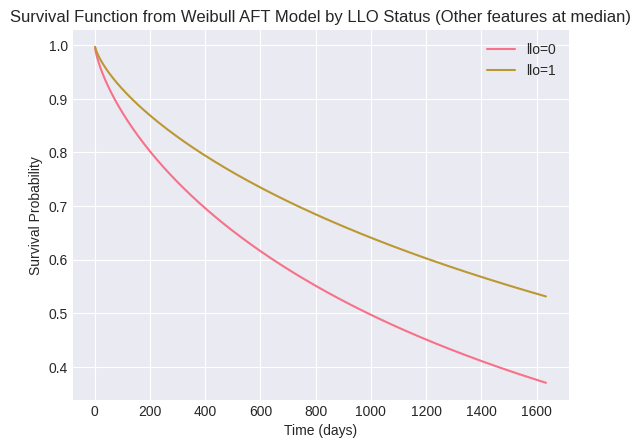


Interpretation of the plot:
This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.


In [34]:
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fit a Weibull AFT model
aft = WeibullAFTFitter()
aft.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
aft.print_summary()

# Evaluate Concordance Index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nAFT Concordance Index: {c_index_aft:.4f}")

# --- Plot Survival Functions ---
# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features.
# Drop 'time' and 'target' as they are not features for prediction.
# 'cph_data_train_scaled' is appropriate here as it was used to fit the 'aft' model.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function using the Weibull AFT model (aft)
aft.predict_survival_function(plot_data).plot()
plt.title('Survival Function from Weibull AFT Model by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.")

## 3. Gradient Boosting

In [5]:
!pip install xgboost lifelines -q


XGBoost Cox Survival C-Index: 0.8776


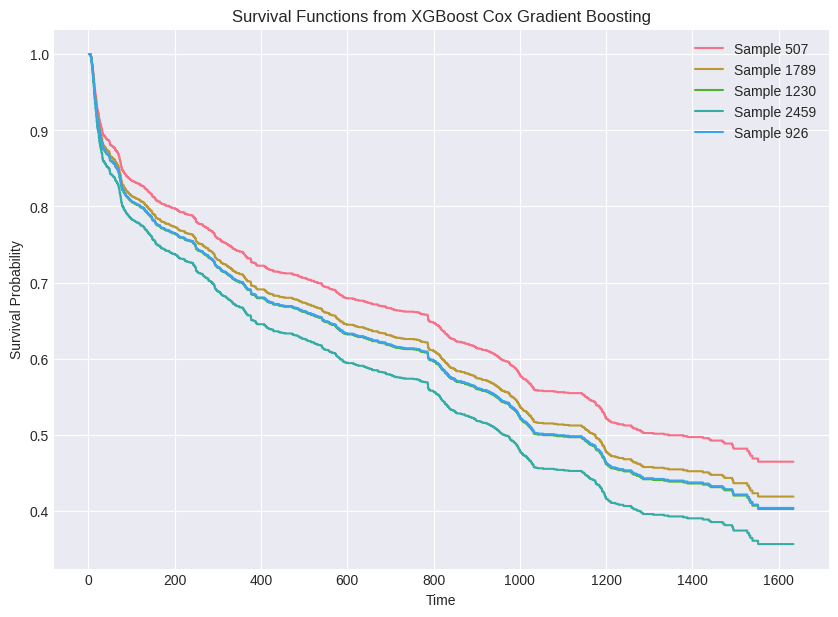

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- 1. Prepare survival data ---
event_train = df_upsampled.loc[y_train.index, "target"].astype(bool).values
time_train = y_train.astype(float).values

event_test = df_upsampled.loc[y_test.index, "target"].astype(bool).values
time_test = y_test.astype(float).values

# XGBoost survival:cox expects:
# positive time = observed event
# negative time = censored
y_train_xgb = np.where(event_train, time_train, -time_train)

# --- 2. Train Gradient Boosting Cox model ---
xgb_surv = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bynode=0.8,
    random_state=42
)

xgb_surv.fit(X_train_sc, y_train_xgb)

# --- 3. Predict risk scores ---



risk_test = xgb_surv.predict(X_test_sc)

# C-index using lifelines
# risk_test: higher = higher risk = shorter survival
# concordance_index expects higher score = longer survival, so use -risk_test
from lifelines.utils import concordance_index

c_index_xgb = concordance_index(
    time_test,
    -risk_test,
    event_test
)

print(f"\nXGBoost Cox Survival C-Index: {c_index_xgb:.4f}")

# --- 4. Estimate baseline survival using CoxPH with XGB risk as one covariate ---
cox_df_train = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "xgb_risk": xgb_surv.predict(X_train_sc)
})

cox_calibrator = CoxPHFitter()
cox_calibrator.fit(
    cox_df_train,
    duration_col="time",
    event_col="event"
)

# --- 5. Plot survival functions for selected test samples ---
sample_indices = [0, 10, 20, 30, 40]
sample_indices = [i for i in sample_indices if i < len(X_test_sc)]

risk_sample = pd.DataFrame({
    "xgb_risk": risk_test[sample_indices]
})

surv_df = cox_calibrator.predict_survival_function(risk_sample)

plt.figure(figsize=(10, 7))

for j, sample_idx in enumerate(sample_indices):
    original_test_index = X_test.index[sample_idx]
    plt.step(
        surv_df.index,
        surv_df.iloc[:, j],
        where="post",
        label=f"Sample {original_test_index}"
    )

plt.title("Survival Functions from XGBoost Cox Gradient Boosting")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

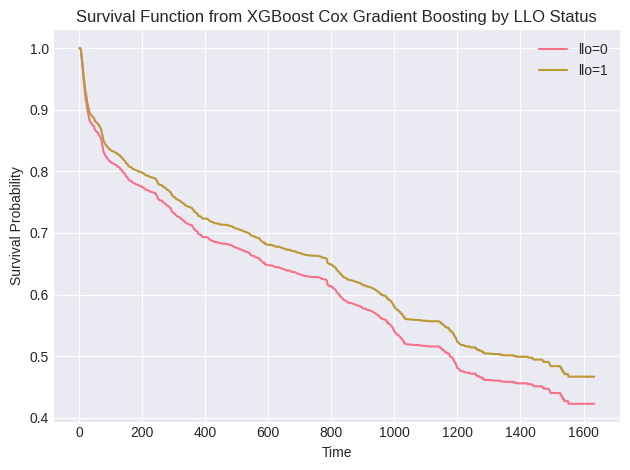


Interpretation of the plot:
This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get median features from the scaled training data used for CPH, excluding time and target
# original_gb_reg_features contains the feature names for X_train_sc
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_gb_reg_features).median().to_frame().T

# Create hypothetical individuals with llo=0 and llo=1, other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_0_scaled['llo'] = (0 - scaler.mean_[original_gb_reg_features.index('llo')]) / scaler.scale_[original_gb_reg_features.index('llo')] # Scale llo=0

pred_llo_1_scaled = median_features_scaled.copy()
pred_llo_1_scaled['llo'] = (1 - scaler.mean_[original_gb_reg_features.index('llo')]) / scaler.scale_[original_gb_reg_features.index('llo')] # Scale llo=1

# Convert to numpy arrays for xgb_surv prediction if it expects it, or ensure DataFrame structure is compatible
# xgb_surv.predict expects a 2D array, so we can convert the single-row DataFrames to numpy
X_pred_llo_0_xgb = pred_llo_0_scaled.values
X_pred_llo_1_xgb = pred_llo_1_scaled.values

# Predict risk scores using the trained XGBoost model
risk_llo_0 = xgb_surv.predict(X_pred_llo_0_xgb)
risk_llo_1 = xgb_surv.predict(X_pred_llo_1_xgb)

# Create a DataFrame for the Cox calibrator
# The cox_calibrator was fit on a DataFrame with a single column 'xgb_risk'
risk_data_for_calibrator = pd.DataFrame({
    'xgb_risk': [risk_llo_0[0], risk_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the cox_calibrator
surv_funcs_xgb = cox_calibrator.predict_survival_function(risk_data_for_calibrator)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_xgb.plot()
plt.title('Survival Function from XGBoost Cox Gradient Boosting by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.")

# Methods comparison

### Model Comparison: Concordance Index (C-index)

                                 C-index
Model                                   
Cox Proportional Hazards          0.8374
Weibull AFT                       0.8370
XGBoost Cox (Gradient Boosting)   0.8776


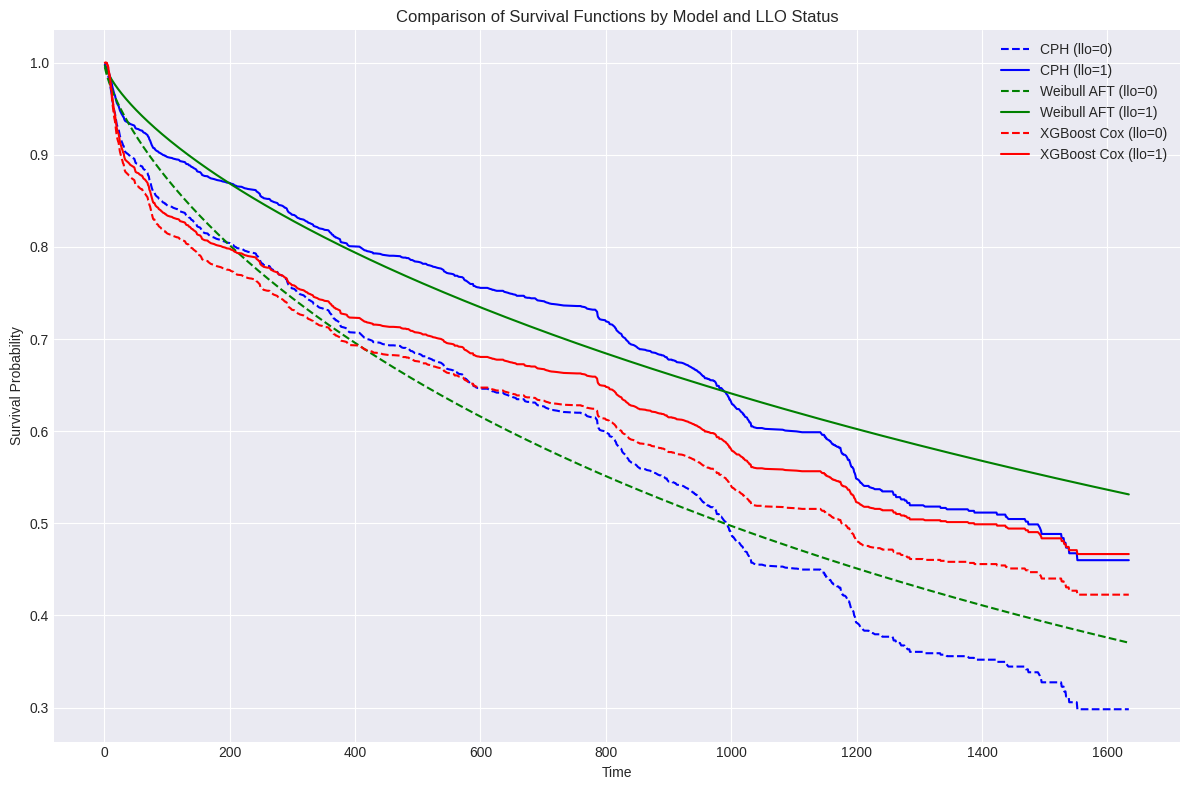


Interpretation of the comparison plot:
- This plot visualizes the predicted survival probabilities over time for a hypothetical individual with LLO=0 (dashed lines) and LLO=1 (solid lines) across all three survival models.
- Each color represents a different model (e.g., blue for CPH, green for Weibull AFT, red for XGBoost Cox).
- By observing the separation and shape of the curves for LLO=0 and LLO=1 within each model, we can understand how each model estimates the impact of the 'llo' feature on survival.
- Comparing curves across different colors (models) allows us to see how their predictions for survival probabilities differ, despite all being trained on the same data. This can highlight consistency or divergence in their prognostic capabilities.


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
from lifelines.utils import concordance_index

# Recalculate C-indices to ensure they are available within this cell
# CPH Model C-index
concordance_index_cph = cph.score(cph_data_test_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index
risk_test_xgb = xgb_surv.predict(X_test_sc)
c_index_xgb = concordance_index(time_test, -risk_test_xgb, event_test)

# 1. Evaluate accuracy (C-index) and plot differences
print("### Model Comparison: Concordance Index (C-index)\n")
c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb]
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting CPH and Weibull models.
# Drop 'time' and 'target' as they are not features for prediction.
median_data_unscaled = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

pred_llo_0_unscaled = median_data_unscaled.copy()
pred_llo_0_unscaled['llo'] = 0
pred_llo_1_unscaled = median_data_unscaled.copy()
pred_llo_1_unscaled['llo'] = 1

# Get survival functions
# CPH Model
sf_cph_llo_0 = cph.predict_survival_function(pred_llo_0_unscaled).iloc[:, 0]
sf_cph_llo_1 = cph.predict_survival_function(pred_llo_1_unscaled).iloc[:, 0]

# Weibull AFT Model
sf_aft_llo_0 = aft.predict_survival_function(pred_llo_0_unscaled).iloc[:, 0]
sf_aft_llo_1 = aft.predict_survival_function(pred_llo_1_unscaled).iloc[:, 0]

# XGBoost Cox Model (surv_funcs_xgb already contains both llo=0 and llo=1 for XGBoost)
# Note: surv_funcs_xgb is expected to be available from cell 8USjV_v4lW6C
sf_xgb_llo_0 = surv_funcs_xgb['llo=0']
sf_xgb_llo_1 = surv_funcs_xgb['llo=1']

# Plotting the survival functions
plt.figure(figsize=(12, 8))

# CPH
plt.plot(sf_cph_llo_0.index, sf_cph_llo_0, label='CPH (llo=0)', linestyle='--', color='blue')
plt.plot(sf_cph_llo_1.index, sf_cph_llo_1, label='CPH (llo=1)', linestyle='-', color='blue')

# Weibull AFT
plt.plot(sf_aft_llo_0.index, sf_aft_llo_0, label='Weibull AFT (llo=0)', linestyle='--', color='green')
plt.plot(sf_aft_llo_1.index, sf_aft_llo_1, label='Weibull AFT (llo=1)', linestyle='-', color='green')

# XGBoost Cox
plt.plot(sf_xgb_llo_0.index, sf_xgb_llo_0, label='XGBoost Cox (llo=0)', linestyle='--', color='red')
plt.plot(sf_xgb_llo_1.index, sf_xgb_llo_1, label='XGBoost Cox (llo=1)', linestyle='-', color='red')

plt.title('Comparison of Survival Functions by Model and LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the comparison plot:")
print("- This plot visualizes the predicted survival probabilities over time for a hypothetical individual with LLO=0 (dashed lines) and LLO=1 (solid lines) across all three survival models.")
print("- Each color represents a different model (e.g., blue for CPH, green for Weibull AFT, red for XGBoost Cox).")
print("- By observing the separation and shape of the curves for LLO=0 and LLO=1 within each model, we can understand how each model estimates the impact of the 'llo' feature on survival.")
print("- Comparing curves across different colors (models) allows us to see how their predictions for survival probabilities differ, despite all being trained on the same data. This can highlight consistency or divergence in their prognostic capabilities.")

In [36]:
import pandas as pd
from lifelines.utils import concordance_index

print("### Survival Model Accuracy Evaluation on Test Set (Concordance Index)\n")

# Ensure C-index values are available from previous cells or re-calculate if necessary
# CPH Model C-index
concordance_index_cph = cph.score(cph_data_test_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index
risk_test_xgb = xgb_surv.predict(X_test_sc)
c_index_xgb = concordance_index(time_test, -risk_test_xgb, event_test)

c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb]
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

print("\nInterpretation of C-index:")
print("- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.")
print("- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.")
print("- All three models demonstrate good predictive performance, with C-index values significantly above 0.5, suggesting they are all better than random chance at predicting survival outcomes.")

### Survival Model Accuracy Evaluation on Test Set (Concordance Index)

                                 C-index
Model                                   
Cox Proportional Hazards          0.8374
Weibull AFT                       0.8370
XGBoost Cox (Gradient Boosting)   0.8776

Interpretation of C-index:
- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.
- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.
- All three models demonstrate good predictive performance, with C-index values significantly above 0.5, suggesting they are all better than random chance at predicting survival outcomes.


# Система предсказания времени дожития

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Prepare data for time prediction (regression)
# Features for regression should be all columns used for classification, minus 'target', plus 'time' is the target
# Ensure 'age_group' is dropped as it is a categorical string column not suitable for scaling/regression directly
X_reg = df_upsampled.drop(['time', 'target', 'age_group'], axis=1)
y_reg = df_upsampled['time']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale numerical features (assuming X_reg contains numerical features that need scaling)
scaler_reg = StandardScaler()
# Identify numerical columns in X_reg for scaling
numerical_cols_reg = X_reg.select_dtypes(include=np.number).columns

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[numerical_cols_reg] = scaler_reg.fit_transform(X_train_reg[numerical_cols_reg])
X_test_reg_scaled[numerical_cols_reg] = scaler_reg.transform(X_test_reg[numerical_cols_reg])

# Train RandomForestRegressor model
rf_reg_prediction = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_prediction.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_time_model = rf_reg_prediction.predict(X_test_reg_scaled)

# Evaluate the model
r2_time_model = r2_score(y_test_reg, y_pred_time_model)
rmse_time_model = np.sqrt(mean_squared_error(y_test_reg, y_pred_time_model))
mae_time_model = mean_absolute_error(y_test_reg, y_pred_time_model)

print("Time Prediction Model Performance (RandomForestRegressor):")
print(f"  R²   = {r2_time_model:.4f}")
print(f"  RMSE = {rmse_time_model:.4f}")
print(f"  MAE  = {mae_time_model:.4f}")

# Display feature importances
feat_imp_reg = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': rf_reg_prediction.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_reg['feature'], feat_imp_reg['importance'])
plt.title('Feature Importances - Time Prediction (RandomForestRegressor)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()